## Building the Schematic! 

In [ ]:
678

In [16]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import xmitgcm as xm
import cmocean
from matplotlib import patches

In [3]:
WOAtest = xr.open_dataset('/glade/work/yeddebba/WOA/woa2023/woa23_all_o00_01.nc', decode_times=False)

# getting the observed Oxygen. 

In [11]:
# import the age contours 

myYr2 = np.arange(90,100)
#print(myYr)
myIts2 = 2880000 + 720*myYr2

GlTrnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Global-4C-O2-Age-Tracers.nc'
GlTr = xr.open_dataset(GlTrnc)

conTrnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Control-O2-Age-Tracers.nc'
CtlTr = xr.open_dataset(conTrnc)


ageGl = xr.where(GlTr.Age ==0, np.nan, GlTr.Age).mean('time')
agecon= xr.where(CtlTr.Age ==0, np.nan, CtlTr.Age).mean('time')



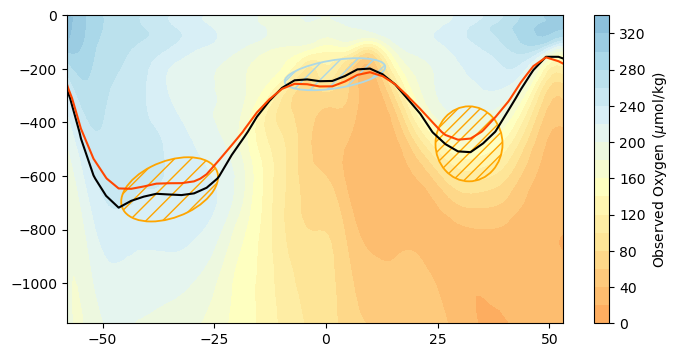

In [35]:
# Schematic of changes


fig, axs = plt.subplots(figsize = (8,4))

yran = range(64)
zran = range(20)
xran = range(64,80)

o2mean= WOAtest.o_an.isel(time=0).isel(lat = np.arange(30,150)).isel(lon=range(45)).isel(depth = range(50)).mean('lon')

A = plt.contourf(o2mean.lat, -o2mean.depth, o2mean, cmap = 'RdYlBu', vmin = -200, vmax = 500, levels = 20) 
cbA = plt.colorbar(A) 
cbA.set_label('Observed Oxygen ($\\mu$mol/kg)')


ageconPl = agecon.isel(Z = zran, YC = yran, XC = xran).mean('XC')
#o2conPl = o2con.isel(Z = zran, YC = yran, XC = xran).mean('XC')
ageGlPl = ageGl.isel(Z = zran, YC = yran, XC = xran).mean('XC')
#o2dif = o2Gl.isel(Z = zran, YC = yran, XC = xran).mean('XC') - o2con.isel(Z = zran, YC = yran, XC = xran).mean('XC')

# Define ellipse parameters
center_x, center_y = 32, -480
width = 15
height = 280
angle = 0  # degrees

# Create an Ellipse object
ellipse = patches.Ellipse((center_x, center_y), width, height, angle=angle, facecolor = 'none', hatch = '///',
                           edgecolor='orange', linewidth=1.3)

# Add the ellipse to the axes
axs.add_patch(ellipse)

# Define ellipse parameters
center_x, center_y = 2, -220
width2 = 20
height2 = 120
angle = -5  # degrees

# Create an Ellipse object
ellipse2 = patches.Ellipse((center_x, center_y), width2, height2, angle=angle, facecolor = 'none', hatch = '//',
                           edgecolor='lightblue', linewidth=1.3)

# Add the ellipse to the axes
axs.add_patch(ellipse2)

# Define ellipse parameters
center_x, center_y = -35, -650
width2 = 20
height2 = 240
angle = -2  # degrees

# Create an Ellipse object
ellipse3 = patches.Ellipse((center_x, center_y), width2, height2, angle=angle, facecolor = 'none', hatch = '//',
                           edgecolor='orange', linewidth=1.3)

# Add the ellipse to the axes
axs.add_patch(ellipse3)


plt.contour(GlTr.YC[yran], GlTr.Z[zran], ageconPl, levels = [150,], colors = 'black')
#plt.contour(GlTr.YC[yran], GlTr.Z[zran], o2conPl, levels = [0.2,], colors = 'darkgray')
cl1 = plt.contour(GlTr.YC[yran], GlTr.Z[zran], ageGlPl, levels = [150,], colors = 'orangered')

#plt.plot(x_smooth, y_smooth, 'r', lw=2, label='smoothed contour')
#plt.plot(x_smooth2, y_smooth2, 'k', lw=2, label='smoothed contour')


plt.xlim([-58,53])
plt.ylim([-1150,0])
axs.locator_params(axis="x", nbins=5)
axs.locator_params(axis="y", nbins=7)
#plt.yticklabels = None




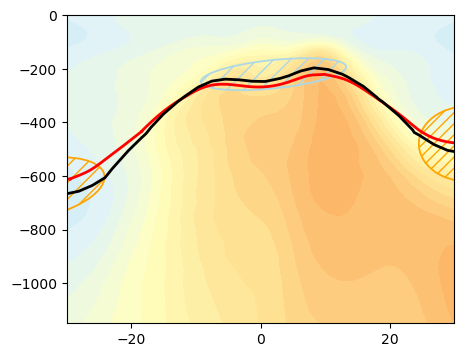

In [167]:
## a slightly different version for just the subtropics.
fig, axs = plt.subplots(figsize = (5,4))
plt.contourf(o2mean.lat, -o2mean.depth, o2mean, cmap = 'RdYlBu', vmin = -200, vmax = 500, levels = 20) 


yran = range(64)
zran = range(20)
xran = range(64,80)
ageconPl = agecon.isel(Z = zran, YC = yran, XC = xran).mean('XC')
#o2conPl = o2con.isel(Z = zran, YC = yran, XC = xran).mean('XC')
ageGlPl = ageGl.isel(Z = zran, YC = yran, XC = xran).mean('XC')
o2dif = o2Gl.isel(Z = zran, YC = yran, XC = xran).mean('XC') - o2con.isel(Z = zran, YC = yran, XC = xran).mean('XC')

# Define ellipse parameters
center_x, center_y = 32, -480
width = 15
height = 280
angle = 0  # degrees

# Create an Ellipse object
ellipse = patches.Ellipse((center_x, center_y), width, height, angle=angle, facecolor = 'none', hatch = '///',
                           edgecolor='orange', linewidth=1.3)

# Add the ellipse to the axes
axs.add_patch(ellipse)

# Define ellipse parameters
center_x, center_y = 2, -220
width2 = 20
height2 = 120
angle = -5  # degrees

# Create an Ellipse object
ellipse2 = patches.Ellipse((center_x, center_y), width2, height2, angle=angle, facecolor = 'none', hatch = '//',
                           edgecolor='lightblue', linewidth=1.3)

# Add the ellipse to the axes
axs.add_patch(ellipse2)

# Define ellipse parameters
center_x, center_y = -35, -650
width2 = 20
height2 = 240
angle = -2  # degrees

# Create an Ellipse object
ellipse3 = patches.Ellipse((center_x, center_y), width2, height2, angle=angle, facecolor = 'none', hatch = '//',
                           edgecolor='orange', linewidth=1.3)

# Add the ellipse to the axes
axs.add_patch(ellipse3)

#plt.contour(GlTr.YC[yran], GlTr.Z[zran], ageconPl, levels = [150,], colors = 'black')
#plt.contour(GlTr.YC[yran], GlTr.Z[zran], o2conPl, levels = [0.2,], colors = 'darkgray')
#cl1 = plt.contour(GlTr.YC[yran], GlTr.Z[zran], ageGlPl, levels = [150,], colors = 'orangered')
plt.plot(x_smooth, y_smooth, 'r', lw=2, label='smoothed contour')
plt.plot(x_smooth2, y_smooth2, 'k', lw=2, label='smoothed contour')


plt.xlim([-30,30])
plt.ylim([-1150,0])
axs.locator_params(axis="x", nbins=4)
axs.locator_params(axis="y", nbins=7)
#plt.yticklabels = None

In [ ]:
# Ok there are 4 or 5 more pieces that'd be really nice to do ! 
# One is to get the hatching done here. 
# A third is to smooth these age lines, and potentially amplify their vertical changes... funky.. 
# 


(-1150.0, 0.0)

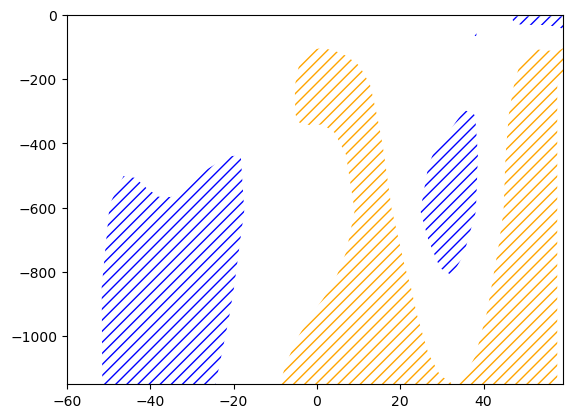

In [103]:
# Let's try the hatching here, that should be fine. 
fig, axs = plt.subplots()
yran
o2dif = o2Gl.isel(Z = zran, YC = yran, XC = xran).mean('XC') - o2con.isel(Z = zran, YC = yran, XC = xran).mean('XC')
plt.rcParams['hatch.color'] = 'blue'
cf2 = plt.contourf(
    GlTr.YC[yran], GlTr.Z[zran], o2dif,
    levels=[-0.05, -0.022],
    colors = "none", 
                 # don't paint solid color
    hatches=['///', "///", 'o'],  
    #edgecolors ='red', # hatch pattern
)
plt.rcParams['hatch.color'] = 'orange'
cf3 = plt.contourf(
    GlTr.YC[yran], GlTr.Z[zran], o2dif,
    levels=[-0.007, 0.1],
    colors = "none", 
                 # don't paint solid color
    hatches=['///', "///", 'o'],  
    #edgecolors ='red', # hatch pattern
)

plt.xlim([-60,59])
plt.ylim([-1150,0])

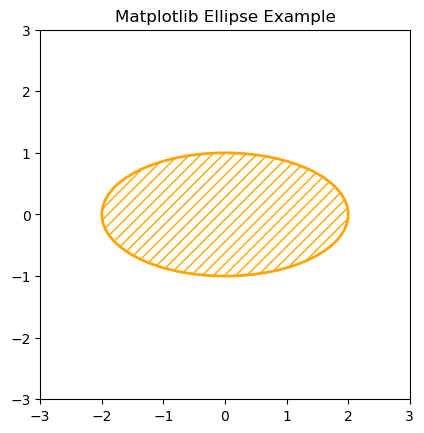

In [117]:
import matplotlib.pyplot as plt
from matplotlib import patches

# Create a figure and an axes object
fig, ax = plt.subplots(subplot_kw={'aspect': 'equal'})

# Define ellipse parameters
center_x, center_y = 0, 0
width = 4
height = 2
angle = 0  # degrees

# Create an Ellipse object
ellipse = patches.Ellipse((center_x, center_y), width, height, angle=angle, facecolor = 'none', hatch = '///',
                           edgecolor='orange', linewidth=2)

# Add the ellipse to the axes
ax.add_patch(ellipse)

# Set plot limits
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

# Set title and display
ax.set_title('Matplotlib Ellipse Example')
plt.show()



/glade/derecho/scratch/bataylor/tmp/ipykernel_70671/3883339260.py:5: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  p = cl1.collections[0].get_paths()[0]


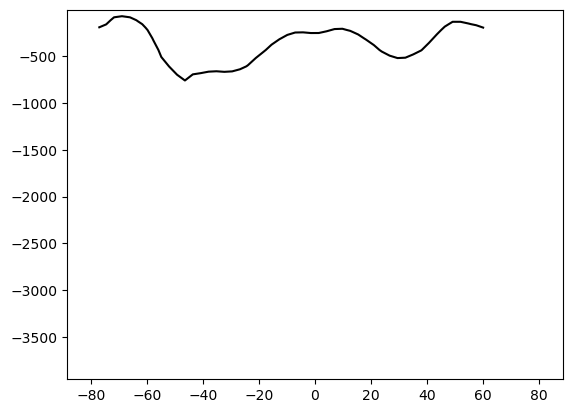

In [27]:
from scipy.interpolate import UnivariateSpline
cl1 = plt.contour(GlTr.YC[yran], GlTr.Z[zran], ageconPl, levels = [150,], colors = 'black')

# Extract the first contour path
p = cl1.collections[0].get_paths()[0]
v = p.vertices  # (N,2) array of x,y points

x, y = v[:,0], v[:,1]

# Smooth with UnivariateSpline
# (parameter `s` controls smoothness)
spl_x = UnivariateSpline(np.arange(len(x)), x, s=0)
spl_y = UnivariateSpline(np.arange(len(y)), y, s=0.1)

t = np.linspace(0, len(x)-1, 100)  # resample smoothly
x_smooth2, y_smooth2 = spl_x(t), spl_y(t)


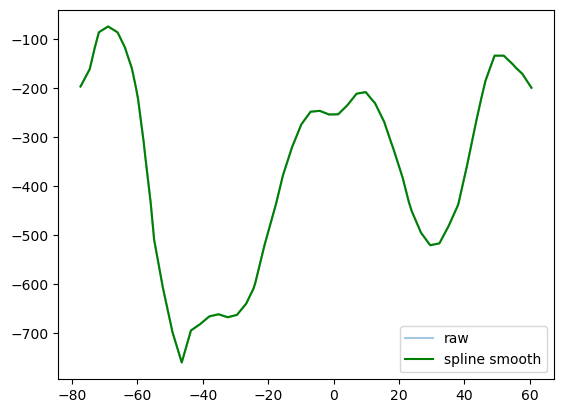

In [19]:
from scipy.interpolate import UnivariateSpline

spl = UnivariateSpline(x, y)
spl.set_smoothing_factor(0.5)  # tweak between 0 (interpolation) and higher (smoother)
y_smooth = spl(x)

plt.plot(x, y, alpha=0.4, label="raw")
plt.plot(x, y_smooth, 'g', label="spline smooth")
plt.legend()
plt.show()


/glade/derecho/scratch/bataylor/tmp/ipykernel_70671/99479133.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  p = cl1.collections[0].get_paths()[0]


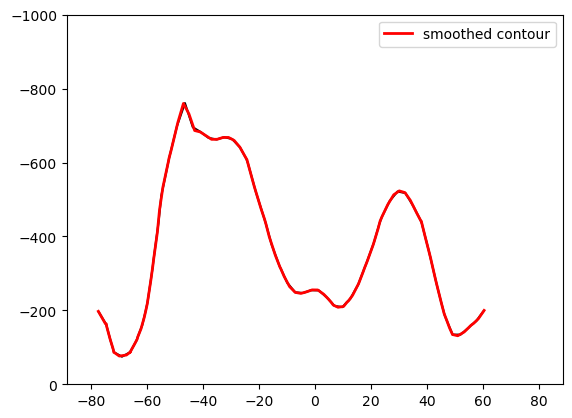

In [26]:
#import numpy as np
#import matplotlib.pyplot as plt
#from scipy.interpolate import UnivariateSpline

# Your contour
#cl1 = plt.contour(
#    GlTr.YC[yran], GlTr.Z[zran], ageGlPl,
#    levels=[150], colors='orangered'
#)

from scipy.interpolate import UnivariateSpline
cl1 = plt.contour(GlTr.YC[yran], GlTr.Z[zran], ageconPl, levels = [150,], colors = 'black')

# Extract the first contour path
p = cl1.collections[0].get_paths()[0]
v = p.vertices  # (N,2) array of x,y points

x, y = v[:,0], v[:,1]

# Smooth with UnivariateSpline
# (parameter `s` controls smoothness)
spl_x = UnivariateSpline(np.arange(len(x)), x, s=0)
spl_y = UnivariateSpline(np.arange(len(y)), y, s=0.1)

t = np.linspace(0, len(x)-1, 100)  # resample smoothly
x_smooth2, y_smooth2 = spl_x(t), spl_y(t)

# Plot results
#plt.plot(x, y, 'k--', alpha=0.5, label='raw contour')
plt.plot(x_smooth2, y_smooth2, 'r', lw=2, label='smoothed contour')
plt.gca().invert_yaxis()  # if depth increases downward
plt.legend()
plt.ylim([0,-1000])
plt.show()


(-1150.0, 0.0)

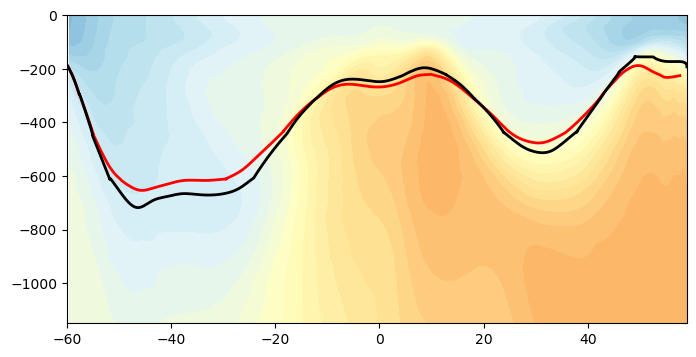

In [70]:
fig, axs = plt.subplots(figsize = (8,4))
plt.contourf(o2mean.lat, -o2mean.depth, o2mean, cmap = 'RdYlBu', vmin = -200, vmax = 500, levels = 20) 


yran = range(64)
zran = range(20)
xran = range(64,80)
ageconPl = agecon.isel(Z = zran, YC = yran, XC = xran).mean('XC')
#o2conPl = o2con.isel(Z = zran, YC = yran, XC = xran).mean('XC')
ageGlPl = ageGl.isel(Z = zran, YC = yran, XC = xran).mean('XC')

#plt.contour(GlTr.YC[yran], GlTr.Z[zran], ageconPl, levels = [150,], colors = 'black')
#plt.contour(GlTr.YC[yran], GlTr.Z[zran], o2conPl, levels = [0.2,], colors = 'darkgray')
#cl1 = plt.contour(GlTr.YC[yran], GlTr.Z[zran], ageGlPl, levels = [150,], colors = 'orangered')
plt.plot(x_smooth, y_smooth, 'r', lw=2, label='smoothed contour')
plt.plot(x_smooth2, y_smooth2, 'k', lw=2, label='smoothed contour')

plt.xlim([-60,59])
plt.ylim([-1150,0])

In [71]:
# there are still kinks at the vertices which aren't great! 

In [ ]:
# OK I really need to go ahead and implement a few more things. 